# 19 - Word2Vec + RNN with Truncated BPTT & Gradient Clipping

Goal: Fix vanishing/exploding gradients problem from Notebook 18 using:
1. **Truncated BPTT** - Only backprop through the last N steps, not the full sequence
2. **Gradient Clipping** - Limit gradient magnitude during updates
3. **LeakyReLU option** - Alternative to tanh with better gradient flow

Why this version is smaller than Notebook 18:
- Very long sequences make a vanilla RNN learn poorly
- Truncation is still useful, but too much context hurts optimization
- Using an intermediate window size gives a better trade-off between context and trainability

Run with: conda activate tfenv

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1779732828.687097    3008 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779732830.420013    3008 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779732836.682474    3008 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/eanorambuena/miniconda/envs/tfenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.21.0


In [2]:
# Cargar embeddings Word2Vec preentrenados
class Word2VecLoader:
    def __init__(self, path='myWord2Vec/v2/'):
        target_embeddings = np.load(path + 'target_embeddings.npy')
        context_embeddings = np.load(path + 'context_embeddings.npy')
        text_vocab = np.load(path + 'text_vocab.npy', allow_pickle=True).item()

        self.target_embeddings = target_embeddings
        self.context_embeddings = context_embeddings
        self.final_embeddings = (target_embeddings + context_embeddings) / 2
        self.text_vocab = text_vocab
        self.idx_to_word = {idx: word for word, idx in text_vocab.items()}
        self.embedding_dim = target_embeddings.shape[1]

        self.embedding_layer = layers.Embedding(
            input_dim=target_embeddings.shape[0],
            output_dim=target_embeddings.shape[1],
            weights=[target_embeddings],
            trainable=False,
            name='pretrained_embedding'
        )

        print('Embeddings cargados:', target_embeddings.shape, context_embeddings.shape)
        print('Vocabulario cargado:', len(text_vocab))

    def encode(self, words):
        return [self.text_vocab[w] for w in words if w in self.text_vocab]

    def decode(self, token_id):
        return self.idx_to_word.get(int(token_id), '<unk>')

loader = Word2VecLoader()

E0000 00:00:1779732846.788731    3008 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779732846.851738    3008 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Embeddings cargados: (3291, 64) (3291, 64)
Vocabulario cargado: 3291


In [3]:
# TRUNCATED BPTT: use a longer context than Notebook 18, but not extreme
# Too many timesteps make optimization much harder for a vanilla RNN
print('Loading gaianet/london dataset...')
ds = load_dataset('gaianet/london', split='train')
texts = [row['text'] if 'text' in row else row.get('content', '') for row in ds][:50000]
full_text = ' '.join(texts[:50000])

words = full_text.lower().split()
words = [w.strip('.,;:!?()[]\"\'\'-0123456789') for w in words]
words = [w for w in words if len(w) > 2 and w in loader.text_vocab]
print(f'Total words used: {len(words)}')
print(f'Sample: {words[:20]}')


def create_sequences(words, window=64, step=5):
    """Create longer sequences for truncated BPTT.

    window=64: enough context without making gradients too brittle
    step=5: reuse more of the corpus for training examples
    """
    X, y = [], []
    for i in range(0, len(words) - window, step):
        context = words[i:i + window]
        target = words[i + window]
        if all(w in loader.text_vocab for w in context + [target]):
            X.append([loader.text_vocab[w] for w in context])
            y.append(loader.text_vocab[target])
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)


X, y = create_sequences(words, window=64)
print(f'Sequences created: {len(X)}')
print(f'Input shape: {X.shape}, Target shape: {y.shape}')

if len(X) == 0:
    raise ValueError('No se pudieron crear secuencias con el vocabulario cargado.')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

Loading gaianet/london dataset...
Total words used: 23651
Sample: ['london', 'the', 'capital', 'and', 'largest', 'city', 'england', 'and', 'the', 'united', 'kingdom', 'with', 'population', 'around', 'million', 'and', 'the', 'largest', 'city', 'western']
Sequences created: 4718
Input shape: (4718, 64), Target shape: (4718,)


In [4]:
# RNN with Truncated BPTT, Gradient Clipping, and optional LeakyReLU
# Solutions:
# 1. Truncated BPTT: backprop only through the last N steps
# 2. Gradient Clipping: clip_norm limits gradient magnitude
# 3. LeakyReLU: alternative to tanh with better gradient flow

class ManualRNNWordPredictorV2(keras.Model):
    def __init__(self, embedding_layer, vocab_size, embed_dim, hidden_dim=128, use_leaky_relu=False, truncate_steps=32):
        super().__init__()
        self.embedding = embedding_layer
        self.hidden_dim = hidden_dim
        self.use_leaky_relu = use_leaky_relu
        self.truncate_steps = truncate_steps

        self.Wx = layers.Dense(hidden_dim, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.0001))
        self.Wh = layers.Dense(hidden_dim, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.0001))
        self.b = self.add_weight(shape=(hidden_dim,), initializer='zeros', trainable=True, name='bias')
        self.out = layers.Dense(vocab_size, activation='softmax')

    def call(self, inputs):
        x = self.embedding(inputs)  # (batch, 64, 64)
        x = tf.nn.dropout(x, rate=0.1)
        h = tf.zeros((tf.shape(x)[0], self.hidden_dim))

        x_unstacked = tf.unstack(x, axis=1)
        sequence_length = len(x_unstacked)

        # Truncated BPTT: stop gradients in the early steps
        for i, xt in enumerate(x_unstacked):
            if self.use_leaky_relu:
                h = tf.nn.leaky_relu(self.Wx(xt) + self.Wh(h) + self.b, alpha=0.2)
            else:
                h = tf.tanh(self.Wx(xt) + self.Wh(h) + self.b)

            if i < sequence_length - self.truncate_steps:
                h = tf.stop_gradient(h)

        return self.out(h)

vocab_size = loader.target_embeddings.shape[0]

# Start with tanh + gradient clipping + truncated BPTT
model = ManualRNNWordPredictorV2(
    loader.embedding_layer,
    vocab_size,
    loader.embedding_dim,
    hidden_dim=64,
    use_leaky_relu=False,
    truncate_steps=32
)

optimizer = keras.optimizers.Adam(learning_rate=0.001, clipnorm=5.0)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.build((None, 64))
model.summary()

batch_size = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(min(len(X_train), 2000)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

callbacks=[keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)]

history = model.fit(train_ds, validation_data=val_ds, epochs=100, verbose=1, callbacks=callbacks)

/home/eanorambuena/miniconda/envs/tfenv/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'manual_rnn_word_predictor_v2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model: "manual_rnn_word_predictor_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ ?                      │       210,624 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,688 (823.00 KB)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 210,624 (822.75 KB)

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.0562 - loss: 7.6713 - val_accuracy: 0.1028 - val_loss: 7.1322
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.1028 - loss: 6.4001 - val_accuracy: 0.1049 - val_loss: 7.1874
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1031 - loss: 6.2598 - val_accuracy: 0.1049 - val_loss: 7.2188
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1031 - loss: 6.1671 - val_accuracy: 0.1049 - val_loss: 7.2824
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1033 - loss: 6.0732 - val_accuracy: 0.1038 - val_loss: 7.2604
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1033 - loss: 5.9654 - val_accuracy: 0.1049 - val_loss: 7.2795
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1047 - loss: 5.8547 - val_accuracy: 0.1017 - val_loss: 7.2752


Test accuracy (tanh + Gradient Clipping + Truncated BPTT): 0.105
Contexto ['london', 'bridge', 'river', 'city', 'center'] -> [('the', 0.10468745231628418), ('and', 0.05412264168262482), ('london', 0.0361797921359539), ('city', 0.01176425814628601), ('was', 0.010235496796667576)]
Contexto ['bank', 'of', 'england', 'is', 'located'] -> [('the', 0.07300831377506256), ('and', 0.04172320291399956), ('london', 0.026836572214961052), ('was', 0.009615917690098286), ('city', 0.009274015203118324)]
Contexto ['queen', 'of', 'england', 'lives', 'in'] -> [('the', 0.09908399730920792), ('and', 0.0534684918820858), ('london', 0.0367460772395134), ('city', 0.011437901295721531), ('was', 0.010221307165920734)]


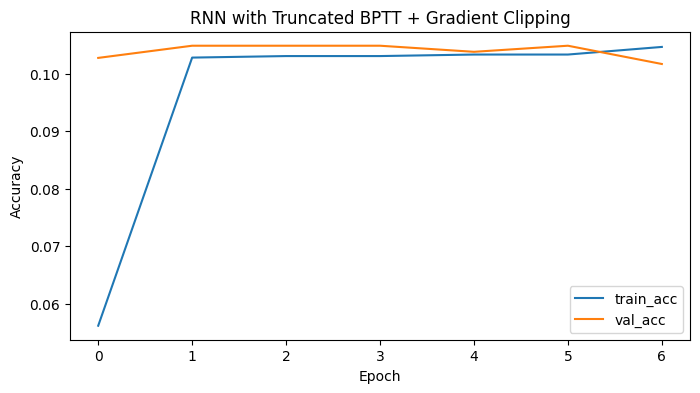

In [5]:
# Evaluation and next-word prediction
from sklearn.metrics import accuracy_score

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy (tanh + Gradient Clipping + Truncated BPTT): {acc:.3f}')


def predict_next_word(context_words, top_n=5, use_last_n=64):
    context_ids = [loader.text_vocab[w] for w in context_words if w in loader.text_vocab]
    if len(context_ids) < use_last_n:
        pad_id = 0
        context_ids = [pad_id] * (use_last_n - len(context_ids)) + context_ids
    context_ids = np.array([context_ids[-use_last_n:]], dtype=np.int32)
    probs = model.predict(context_ids, verbose=0)[0]
    top_indices = np.argsort(probs)[-top_n:][::-1]
    return [(loader.decode(idx), float(probs[idx])) for idx in top_indices]

sample_contexts = [
    ['london', 'bridge', 'river', 'city', 'center'],
    ['bank', 'of', 'england', 'is', 'located'],
    ['queen', 'of', 'england', 'lives', 'in']
]

for context in sample_contexts:
    preds = predict_next_word(context, top_n=5)
    if preds:
        print(f"Contexto {context} -> {preds}")

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('RNN with Truncated BPTT + Gradient Clipping')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


=== Trying LeakyReLU instead of tanh ===


/home/eanorambuena/miniconda/envs/tfenv/lib/python3.12/site-packages/keras/src/layers/layer.py:427: UserWarning: `build()` was called on layer 'manual_rnn_word_predictor_v2_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Test accuracy (LeakyReLU + Gradient Clipping + Truncated BPTT): 0.119

Comparación:
  tanh + Gradient Clipping + Truncated BPTT: 0.105
  LeakyReLU + Gradient Clipping + Truncated BPTT: 0.119


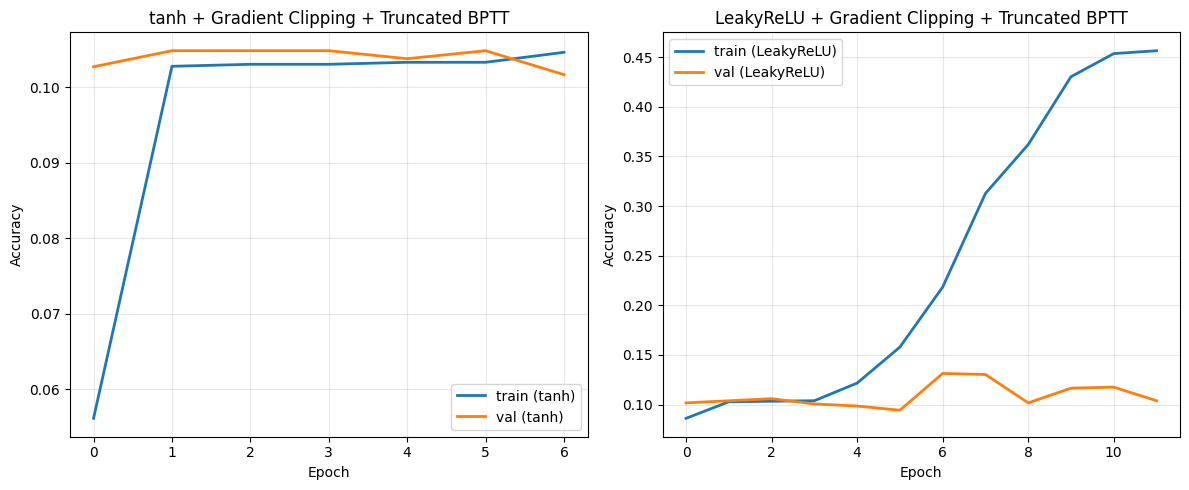

In [6]:
# OPTION 2: If tanh + clipping is not enough, try LeakyReLU
# LeakyReLU keeps a non-zero gradient flow

print("\n=== Trying LeakyReLU instead of tanh ===")
model_leaky = ManualRNNWordPredictorV2(
    loader.embedding_layer,
    vocab_size,
    loader.embedding_dim,
    hidden_dim=64,
    use_leaky_relu=True,
    truncate_steps=32
)

optimizer_leaky = keras.optimizers.Adam(learning_rate=0.001, clipnorm=5.0)
model_leaky.compile(optimizer=optimizer_leaky, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_leaky.build((None, 64))

history_leaky = model_leaky.fit(train_ds, validation_data=val_ds, epochs=100, verbose=0, callbacks=callbacks)

loss_leaky, acc_leaky = model_leaky.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy (LeakyReLU + Gradient Clipping + Truncated BPTT): {acc_leaky:.3f}')

# Compare both models
print(f"\nComparación:")
print(f"  tanh + Gradient Clipping + Truncated BPTT: {acc:.3f}")
print(f"  LeakyReLU + Gradient Clipping + Truncated BPTT: {acc_leaky:.3f}")

# Plot both
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train (tanh)', linewidth=2)
plt.plot(history.history['val_accuracy'], label='val (tanh)', linewidth=2)
plt.title('tanh + Gradient Clipping + Truncated BPTT')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_leaky.history['accuracy'], label='train (LeakyReLU)', linewidth=2)
plt.plot(history_leaky.history['val_accuracy'], label='val (LeakyReLU)', linewidth=2)
plt.title('LeakyReLU + Gradient Clipping + Truncated BPTT')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()